#Physics-informed Neural Networks (PINN)


We have been given a PDE:

* du/dx=2du/dt+u

and boundary condition:

* u(x,0)=6e^(-3x)

Independent variables: x,t (input)

Dependent variables: u (outputs)

We have to find out u(x,t) for all x in range [0,2] and t in range [0,1]

When we solved this problem analytically, we found the solution:

u(x,t) = 6e^(-3x-2t)

Our f is f = du/dx - 2du/dt - u

<!--
* NN as an universal function approximator

  Given:

    Some measured data from initial and boundary conditions
    ODE or PDE
$$\frac{\delta U}{\delta t} - \lambda\frac{\delta^2 U}{\delta x^2}= 0$$



* Adding constraints for regularization
Regularized by physics, but matched with sparse data -->

In [ ]:
import torch
import torch.nn as nn
from torch.autograd import Variable
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

import numpy as np

from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
import numpy as np
import matplotlib.pylab as plt

Define our NN structure:

In [ ]:
class simple_PINN(nn.Module):
  def __init__(self):
        super(simple_PINN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(2,5),
            nn.Sigmoid(),
            nn.Linear(5,5),
            nn.Sigmoid(),
            nn.Linear(5,5),
            nn.Sigmoid(),
            nn.Linear(5,5),
            nn.Sigmoid(),
            nn.Linear(5,5),
            nn.Sigmoid(),
            nn.Linear(5, 1)
        )
  def forward(self, x,t):
    inputs = torch.cat([x,t],axis=1)
    output = self.net(inputs)
    return output

In [ ]:
net = simple_PINN()
net = net.to(device)
mse_cost_function = torch.nn.MSELoss() # Mean squared error
optimizer = torch.optim.Adam(net.parameters())

## Loss

Loss = prediction_loss + pde_loss + bc_loss

- prediction_loss - how well can we predict target values (if exist)
- pde_loss - how well out prediction matches PDE
- bc_loss - how well out prediction matches boundary conditions

pde_loss part:

In [ ]:
def f(x,t, net):
    u = net(x,t) # the dependent variable u is given by the network based on independent variables x,t
    ## Based on our f = du/dx - 2du/dt - u, we need du/dx and du/dt
    u_x = torch.autograd.grad(u.sum(), x, create_graph=True)[0]
    u_t = torch.autograd.grad(u.sum(), t, create_graph=True)[0]
    pde = u_x - 2*u_t - u
    return pde

bc_loss init:

In [ ]:
x_bc = np.random.uniform(low=0.0, high=2.0, size=(500,1))
t_bc = np.zeros((500,1))
# compute u based on BC
u_bc = 6*np.exp(-3*x_bc)

Train loop:

In [ ]:
iterations = 20000
previous_validation_loss = 99999999.0
for epoch in range(iterations):
    optimizer.zero_grad() # to make the gradients zero

    # Loss based on boundary conditions
    pt_x_bc = Variable(torch.from_numpy(x_bc).float(), requires_grad=False).to(device)
    pt_t_bc = Variable(torch.from_numpy(t_bc).float(), requires_grad=False).to(device)
    pt_u_bc = Variable(torch.from_numpy(u_bc).float(), requires_grad=False).to(device)

    net_bc_out = net(pt_x_bc, pt_t_bc) # output of u(x,t)
    mse_u = mse_cost_function(net_bc_out, pt_u_bc)

    # Loss based on PDE
    x_collocation = np.random.uniform(low=0.0, high=2.0, size=(500,1))
    t_collocation = np.random.uniform(low=0.0, high=1.0, size=(500,1))
    all_zeros = np.zeros((500,1))


    pt_x_collocation = Variable(torch.from_numpy(x_collocation).float(), requires_grad=True).to(device)
    pt_t_collocation = Variable(torch.from_numpy(t_collocation).float(), requires_grad=True).to(device)
    pt_all_zeros = Variable(torch.from_numpy(all_zeros).float(), requires_grad=False).to(device)

    f_out = f(pt_x_collocation, pt_t_collocation, net) # output of f(x,t)
    mse_f = mse_cost_function(f_out, pt_all_zeros)

    # Combining the loss functions
    loss = mse_u + mse_f


    loss.backward() # This is for computing gradients using backward propagation
    optimizer.step() # This is equivalent to : theta_new = theta_old - alpha * derivative of J w.r.t theta

    with torch.autograd.no_grad():
    	print(epoch,"Traning Loss:",loss.data)


Let's check our NN predictions:

In [ ]:
#True func
def true_func(x, t):
  return 6. * np.exp(-3 * x -2 * t)

In [ ]:
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

x=np.arange(0,2,0.02)
t=np.arange(0,1,0.02)
ms_x, ms_t = np.meshgrid(x, t)
## Just because meshgrid is used, we need to do the following adjustment
x = np.ravel(ms_x).reshape(-1,1)
t = np.ravel(ms_t).reshape(-1,1)

pt_x = Variable(torch.from_numpy(x).float(), requires_grad=True).to(device)
pt_t = Variable(torch.from_numpy(t).float(), requires_grad=True).to(device)
pt_u = net(pt_x,pt_t)
u=pt_u.data.cpu().numpy()
ms_u = u.reshape(ms_x.shape)

surf = ax.plot_surface(ms_x,ms_t,ms_u, cmap=cm.coolwarm,linewidth=0, antialiased=False)

ax.zaxis.set_major_locator(LinearLocator(10))
ax.zaxis.set_major_formatter(FormatStrFormatter('%.02f'))

fig.colorbar(surf, shrink=0.5, aspect=5)
plt.title("NN")
plt.show()


fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
u = true_func(x, t)
ms_u = u.reshape(ms_x.shape)

surf = ax.plot_surface(ms_x,ms_t,ms_u, cmap=cm.coolwarm,linewidth=0, antialiased=False)

ax.zaxis.set_major_locator(LinearLocator(10))
ax.zaxis.set_major_formatter(FormatStrFormatter('%.02f'))

fig.colorbar(surf, shrink=0.5, aspect=5)
plt.title("True")
plt.show()


## Another example: harmonic oscillator

$\frac{\delta^2 x}{\delta t^2} + \omega^2 x = 0$

Let's consider the case with:

$x(0)$ = x_0$

$\dot{x}(0) = 0$


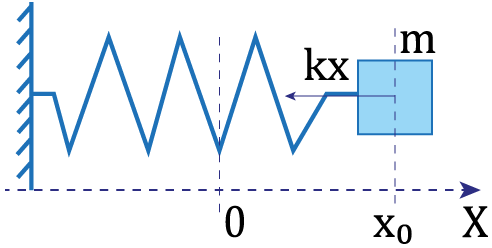

where

$\omega = \sqrt{\frac{k}{m}}$



SPOILER:
The answer is $x(t)=x_0cos(\omega t)$

NN class:

In [ ]:
class simpleModel(nn.Module):
  def __init__(self,
               hidden_size=20):
    super().__init__()
    self.layers_stack = nn.Sequential(
        nn.Linear(1, hidden_size),
        nn.Tanh(),
        nn.Linear(hidden_size, hidden_size), #1
        nn.Tanh(),
        nn.Linear(hidden_size, hidden_size), #2
        nn.Tanh(),
        nn.Linear(hidden_size, hidden_size), #3
        nn.Tanh(),
        nn.Linear(hidden_size, hidden_size), #4
        nn.Tanh(),
        nn.Linear(hidden_size, 1),
        nn.Tanh(),
    )

  def forward(self, x):
    return self.layers_stack(x)

Now we need to implement all elements of our PINN loss:

In [ ]:
model = simpleModel()

nu=2
omega = 2 * torch.pi * nu

steps=20000

t = (torch.linspace(0, 1, 100).unsqueeze(1)).to(device)
t.requires_grad = True

x0_true=torch.tensor([1], dtype=float).float().to(device)
dx0dt_true=torch.tensor([0], dtype=float).float().to(device)

metric_data = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.003)

In [ ]:
def pde(out, t, nu=2):

#    *YOUR CODE HERE*



def pdeBC(t):
  #    *YOUR CODE HERE*


 #   loss_bc =
 #   loss_pde =
 # use this wights:
    loss = 1e3*loss_bc + loss_pde

    return loss

Train loop:

In [ ]:
for i in range(steps):
  optimizer.zero_grad()
  loss = pdeBC(t)
  loss.backward()
  optimizer.step()
  if i % 100 == 0:
    print(loss)


Let's check the results:

In [ ]:
fs=13
t = torch.linspace(0, 1, 100).unsqueeze(-1).unsqueeze(0).to(device)
t.requires_grad=True
x_pred = model(t.float())

x_true = x0_true * torch.cos(omega*t)


plt.scatter(t[0].cpu().detach().numpy(), x_pred[0].cpu().detach().numpy(), label='pred',
            marker='o',
            alpha=.7,
            s=50)
plt.plot(t[0].cpu().detach().numpy(),x_true[0].cpu().detach().numpy(),
         color='blue',
         label='analytical')

plt.xlabel('t', fontsize=fs)
plt.ylabel('x(t)', fontsize=fs)
plt.xticks(fontsize=fs)
plt.yticks(fontsize=fs)
plt.legend()
plt.title('x(t)')
plt.savefig('x.png')
plt.show()

And what about $\dot{x}$?

In [ ]:
dxdt = torch.autograd.grad(x_pred, t, torch.ones_like(t), create_graph=True, \
                    retain_graph=True)[0]
dxdt = dxdt.cpu().detach().numpy()[0]

dxdt_true = -x0_true*omega * torch.sin(omega*t)

plt.scatter(t[0].cpu().detach().numpy(), dxdt, label='pred',
            marker='o',
            alpha=.7,
            s=50,
            color='darkviolet')
plt.plot(t[0].cpu().detach().numpy(),dxdt_true[0].cpu().detach().numpy(),
         color='darkviolet',
         label='analytical')
plt.xlabel('t', fontsize=fs)
plt.ylabel('dx/dt', fontsize=fs)
plt.xticks(fontsize=fs)
plt.yticks(fontsize=fs)
plt.legend()
plt.title('dx/dt (t)')
plt.savefig('dxdt.png')
plt.show()


In [ ]:
#What if no pinn?
model2 = simpleModel()
steps=2000

t = (torch.linspace(0, 1, 100).unsqueeze(1)).to(device)
t.requires_grad = False

metric_data = nn.MSELoss()

y = x0_true * torch.cos(omega*t)

optimizer = torch.optim.Adam(model2.parameters(), lr=0.001)

for i in range(steps):

  optimizer.zero_grad()
  out = model2(t)
  loss = metric_data(out, y)
  loss.backward()
  optimizer.step()
  if i % 100 == 0:
    print(loss)

In [ ]:
fs=13
t = torch.linspace(0, 1, 100).unsqueeze(-1).unsqueeze(0).to(device)
t.requires_grad=True
x_pred = model2(t.float())

x_true = x0_true * torch.cos(omega*t)


plt.scatter(t[0].cpu().detach().numpy(), x_pred[0].cpu().detach().numpy(), label='pred',
            marker='o',
            alpha=.7,
            s=50)
plt.plot(t[0].cpu().detach().numpy(),x_true[0].cpu().detach().numpy(),
         color='blue',
         label='analytical')

plt.xlabel('t', fontsize=fs)
plt.ylabel('x(t)', fontsize=fs)
plt.xticks(fontsize=fs)
plt.yticks(fontsize=fs)
plt.legend()
plt.title('x(t)')
plt.savefig('x.png')
plt.show()


dxdt = torch.autograd.grad(x_pred, t, torch.ones_like(t), create_graph=True, \
                    retain_graph=True)[0]
dxdt = dxdt.cpu().detach().numpy()[0]

dxdt_true = -x0_true*omega * torch.sin(omega*t)

plt.scatter(t[0].cpu().detach().numpy(), dxdt, label='pred',
            marker='o',
            alpha=.7,
            s=50,
            color='darkviolet')
plt.plot(t[0].cpu().detach().numpy(),dxdt_true[0].cpu().detach().numpy(),
         color='darkviolet',
         label='analytical')
plt.xlabel('t', fontsize=fs)
plt.ylabel('dx/dt', fontsize=fs)
plt.xticks(fontsize=fs)
plt.yticks(fontsize=fs)
plt.legend()
plt.title('dx/dt (t)')
plt.savefig('dxdt.png')
plt.show()


# GNN - PyTorch Geometric

PyTorch Geometric (PyG) is an extension library for PyTorch. It provides useful primitives for developing Graph Deep Learning models, including various layers of graph neural networks and a large number of datasets.
Material taken from https://colab.research.google.com/drive/1h3-vJGRVloF5zStxL5I0rSy4ZUPNsjy8?usp=sharing#scrollTo=ci-LpZWhRJoI by Matthias Fey.

In [ ]:
import networkx as nx

# Visualization function for NX graph or PyTorch tensor
def visualize(h, color, epoch=None, loss=None):
    plt.figure(figsize=(7,7))
    plt.xticks([])
    plt.yticks([])

    if torch.is_tensor(h):
        h = h.detach().cpu().numpy()
        plt.scatter(h[:, 0], h[:, 1], s=140, c=color, cmap="Set2")
        if epoch is not None and loss is not None:
            plt.xlabel(f'Epoch: {epoch}, Loss: {loss.item():.4f}', fontsize=16)
    else:
        nx.draw_networkx(G, pos=nx.spring_layout(G, seed=42), with_labels=False,
                         node_color=color, cmap="Set2")
    plt.show()



!pip uninstall torch-scatter torch-sparse torch-geometric torch-cluster  --y
!pip install torch-scatter -f https://data.pyg.org/whl/torch-{torch.__version__}.html
!pip install torch-sparse -f https://data.pyg.org/whl/torch-{torch.__version__}.html
!pip install torch-cluster -f https://data.pyg.org/whl/torch-{torch.__version__}.html
!pip install git+https://github.com/pyg-team/pytorch_geometric.git
!pip install -q torch-geometric

## Introduction

Recently, deep learning on graphs has become one of the hottest research areas in the deep learning community. Here, Graph Neural Networks (GNNs) aims to generalize classical deep learning concepts to irregular structured data (as opposed to images or texts) and to enable neural networks to reason about objects and their relations.

This tutorial will introduce you to some fundamental concepts of deep learning on graphs using graph neural networks based on the PyTorch Geometric (PyG) library. PyTorch Geometric is an extension library to the popular PyTorch deep learning framework, consisting of various methods and utilities to facilitate the implementation of graph neural networks.

Following Kipf et al. (2017), let's dive into the world of GNNs by considering a simple graph-structured example, the well-known Zachary's karate club network. This graph describes a social network of 34 karate club members and documents the connections between members who interacted outside the club. Here, we are interested in discovering the communities that emerge from the interactions of club members.

## Dataset

In [ ]:
from torch_geometric.datasets import KarateClub

dataset = KarateClub()
print(f'Dataset: {dataset}:')
print('======================')
print(f'Number of graphs: {len(dataset)}')
print(f'Number of features: {dataset.num_features}')
print(f'Number of classes: {dataset.num_classes}')

In [ ]:
data = dataset[0]  # Get the first graph object.

print(data)
print('==============================================================')

# Gather some statistics about the graph.
print(f'Number of nodes: {data.num_nodes}')
print(f'Number of edges: {data.num_edges}')
print(f'Average node degree: {data.num_edges / data.num_nodes:.2f}')
print(f'Number of training nodes: {data.train_mask.sum()}')
print(f'Training node label rate: {int(data.train_mask.sum()) / data.num_nodes:.2f}')
print(f'Contains isolated nodes: {data.has_isolated_nodes()}')
print(f'Contains self-loops: {data.has_self_loops()}')
print(f'Is undirected: {data.is_undirected()}')

Each graph in PyTorch Geometric is represented by a single [`Data`](https://pytorch-geometric.readthedocs.io/en/latest/modules/data.html#torch_geometric.data.Data) object, which contains all the information to describe the graph representation.
We can print the data object at any time via `print(data)` to get brief information about its attributes and their shapes:
```
Data(x=[34, 34], edge_index=[2, 156], y=[34], train_mask=[34])
```
We can see that this `data` object contains 4 attributes:
(1) The `edge_index` property contains information about the **connectivity of the graph**, *i.e.*, a tuple of source and destination node indices for each edge.
PyG then calls (2) **node features** `x` (each of the 34 nodes is assigned a 34-dimensional feature vector), and (3) **node labels** `y` (each node is assigned exactly one class).
(4) There is also an additional attribute `train_mask`, which describes for which nodes we already know the community assignments.
In general, we only know the true labels of 4 nodes (one for each community), and the task is to derive the community assignments for the remaining nodes.


The `data` object also provides some **useful functions** to infer some basic properties of the underlying graph.
For example, we can easily determine if there are isolated nodes in the graph (*that is,* there is no edge to any node), if the graph contains self-loops (*th. i.e.*, $(v, v) \in \mathcal{E}$), or whether the graph is undirected (*i.e.*, for every edge $(v, w) \in \mathcal{E}$, there is also an edge $(w, v) \in \mathcal{E}$).


In [ ]:
from IPython.display import Javascript  # Restrict height of output cell.
display(Javascript('''google.colab.output.setIframeHeight(0, true, {maxHeight: 300})'''))

edge_index = data.edge_index
print(edge_index.t())

By printing `edge_index`, we can understand how PyG represents the internal connectivity of a graph.
We see that for each edge, `edge_index` contains a tuple of two node indices, where the first value describes the index of the source node and the second value describes the index of the destination node of the edge.

This representation is known as the **COO (coordinate format)** format, commonly used to represent sparse matrices.
Instead of storing the adjacency information in the dense representation $\mathbf{A} \in \{ 0, 1 \}^{|\mathcal{V}| \times |\mathcal{V}|}$, PyG represents graphs sparsely, which means storing only those coordinates/values for which the entries in $\mathbf{A}$$ are non-zero.

We can further visualize the graph by converting it to the format of the `networkx` library, which implements powerful visualization tools in addition to graph manipulation functions:


In [ ]:
from torch_geometric.utils import to_networkx

G = to_networkx(data, to_undirected=True)
visualize(G, color=data.y)

In [ ]:
# visualize(to_networkx(data, to_undirected=True), color=data.train_mask)

## Implementing graph neural networks

After getting familiar with data processing in PyG, it's time to implement our first graph neural network!

For this we will use one of the simplest GNN operators, the **GCN** layer ([Kipf et al. (2017)](https://arxiv.org/abs/1609.02907)).

PyG implements this layer via [`GCNConv`](https://pytorch-geometric.readthedocs.io/en/latest/modules/nn.html#torch_geometric.nn.conv.GCNConv), which can be executed by passing a node's feature representation `x` and a coordinate representation of the graph connectivity `edge_index`.

Thus, we are ready to create our first graph neural network by defining the network architecture in the `torch.nn.Module` class:


In [ ]:
import torch
from torch.nn import Linear
from torch_geometric.nn import GCNConv


class GCN(torch.nn.Module):
    def __init__(self):
        super(GCN, self).__init__()
        torch.manual_seed(12345)
        self.conv1 = GCNConv(dataset.num_features, 4)
        self.conv2 = GCNConv(4, 4)
        self.conv3 = GCNConv(4, 2)
        self.classifier = Linear(2, dataset.num_classes)

    def forward(self, x, edge_index):
        h = self.conv1(x, edge_index)
        h = h.tanh()
        h = self.conv2(h, edge_index)
        h = h.tanh()
        h = self.conv3(h, edge_index)
        h = h.tanh()  # Final GNN embedding space.

        # Apply a final (linear) classifier.
        out = self.classifier(h)

        return out, h

model = GCN()
print(model)

Here we first initialize all our building blocks in `__init__` and define the computation flow of our network in `forward`.
We first define and stack **three layers of graph convolution**, which corresponds to aggregating 3-hop neighborhood information around each node (all nodes up to 3 hops (“hops”) away).
In addition, `GCNConv` layers reduce the dimensionality of node characteristics to $2$, i.e., $34 \rightarrow 4 \rightarrow 4 \rightarrow 4 \rightarrow 4 \rightarrow 2$. Each layer of `GCNConv` is enhanced by the nonlinearity [tanh](https://pytorch.org/docs/stable/generated/torch.nn.Tanh.html?highlight=tanh#torch.nn.Tanh).

We then apply a single linear transformation ([`torch.nn.Linear`](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html?highlight=linear#torch.nn.Linear)), which acts as a classifier to assign our nodes to 1 of the 4 classes/communities.

We return both the output of the final classifier and the final node embeddings generated by our GNN.
We initialize our final model with `GCN()`, and printing our model outputs a summary of all sub-modules used.


In [ ]:
model = GCN()

_, h = model(data.x, data.edge_index)
print(f'Embedding shape: {list(h.shape)}')

visualize(h, color=data.y)

Remarkably, even before training the weights of our model, the model produces a node embedding that closely resembles the community structure of a graph.
Nodes of the same color (community) are already tightly clustered together in the embedding space, even though the weights of our model are initialized **completely random** and we have not yet performed any training!
This suggests that GNNs introduce a strong inductive bias, leading to similar embeddings for nodes that are close to each other in the input graph.

#### Training on the karate club network

But can we do better than this? Let's look at an example of training our network parameters based on knowledge of community embeddings of 4 nodes in the graph (one for each community):

Since everything in our model is differentiable and parameterizable, we can add some labels, train the model and observe the response of the embeddings.
Here we use a semi-supervised or transductive learning procedure: We simply train on one node for each class, but we are allowed to use all the inputs of the graph.

Training our model is very similar to training any other PyTorch model.
In addition to defining the network architecture, we define a loss criterion (here [`CrossEntropyLoss`](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html)) and initialize a stochastic gradient optimizer (here [`Adam`](https://pytorch.org/docs/stable/optim.html?highlight=adam#torch.optim.Adam)).
We then perform several rounds of optimization, where each round consists of a forward pass and a backward pass to compute the gradients of our model parameters with respect to the losses obtained from the forward pass.
If you are not new to PyTorch, this scheme should sound familiar to you.
Otherwise, the PyTorch documentation has [a good introduction on how to train a neural network in PyTorch] (https://pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html#define-a-loss-function-and-optimizer).


Note that our semi-supervised learning scenario is achieved by the following line:
```
loss = criterion(out[data.train_mask], data.y[data.train_mask])
```
Although we compute node embeddings for all our nodes, we **use only training nodes to compute loss**.
This is implemented here by filtering the output of the classifier `out` and ground-truth labels `data.y` to contain only the nodes in `train_mask`.

Let's now start training and see how our node embeddings change over time (best seen by explicitly executing the code):


In [ ]:
import time
from IPython.display import Javascript  # Restrict height of output cell.
display(Javascript('''google.colab.output.setIframeHeight(0, true, {maxHeight: 430})'''))

model = GCN()
criterion = torch.nn.CrossEntropyLoss()  # Define loss criterion.
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)  # Define optimizer.

def train(data):
    optimizer.zero_grad()  # Clear gradients.
    out, h = model(data.x, data.edge_index)  # Perform a single forward pass.
    loss = criterion(out[data.train_mask], data.y[data.train_mask])  # Compute the loss solely based on the training nodes.
    loss.backward()  # Derive gradients.
    optimizer.step()  # Update parameters based on gradients.
    return loss, h

for epoch in range(401):
    loss, h = train(data)
    # Visualize the node embeddings every 10 epochs
    if epoch % 10 == 0:
        visualize(h, color=data.y, epoch=epoch, loss=loss)
        time.sleep(0.3)

As we can see, our three-layer GCN model handles linear community partitioning and correctly classifies most of the nodes.

Moreover, we did all this with a few lines of code, thanks to the PyTorch Geometric library, which helped us with data processing and GNN implementation.
